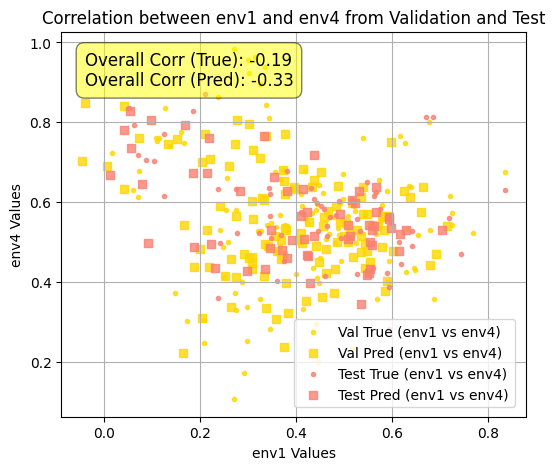

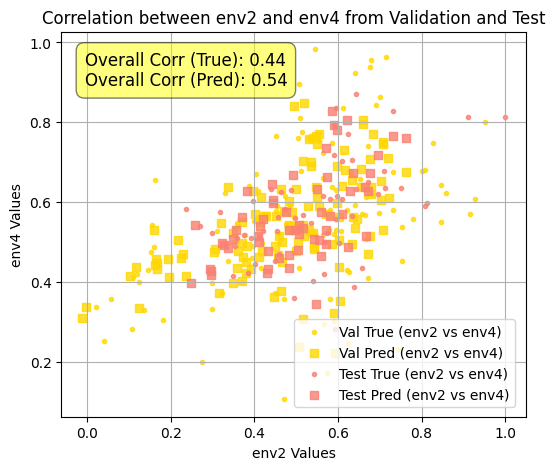

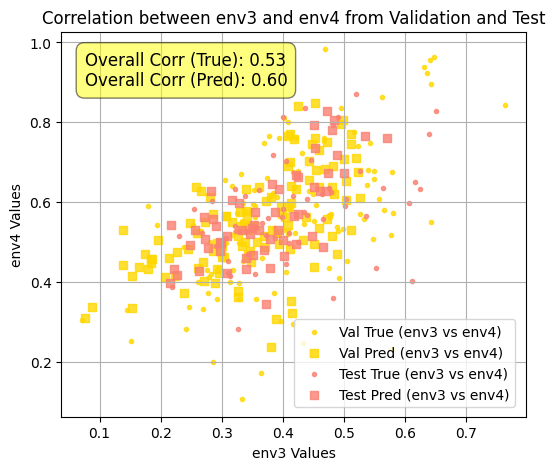

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

def plot_phenotype_correlation(phenotype1_prefix, phenotype2_prefix, val_csv_filepath=None, test_csv_filepath=None, train_csv_filepath=None):
    """
    绘制两个表型预测值和真实值之间的相关图。
    可以从单独的 val, test, 和 train CSV 文件加载数据。
    根据数据集来源（val, test, train）使用不同颜色。
    预测值和真实值使用不同形状的点。

    参数:
    phenotype1_prefix (str): 第一个表型的前缀 (例如 'DTA').
    phenotype2_prefix (str): 第二个表型的前缀 (例如 'DTT').
    val_csv_filepath (str, optional): 验证集 CSV 文件的路径。
    test_csv_filepath (str, optional): 测试集 CSV 文件的路径。
    train_csv_filepath (str, optional): 训练集 CSV 文件的路径。
    """
    dfs = []
    sources = []

    if val_csv_filepath:
        try:
            df_val = pd.read_csv(val_csv_filepath)
            df_val['split'] = 'val'
            dfs.append(df_val)
            sources.append('Validation')
        except FileNotFoundError:
            print(f"警告: 验证集文件未找到 {val_csv_filepath}")
        except Exception as e:
            print(f"读取验证集 CSV 文件时出错: {e}")

    if test_csv_filepath:
        try:
            df_test = pd.read_csv(test_csv_filepath)
            df_test['split'] = 'test'
            dfs.append(df_test)
            sources.append('Test')
        except FileNotFoundError:
            print(f"警告: 测试集文件未找到 {test_csv_filepath}")
        except Exception as e:
            print(f"读取测试集 CSV 文件时出错: {e}")

    if train_csv_filepath:
        try:
            df_train = pd.read_csv(train_csv_filepath)
            df_train['split'] = 'train'
            dfs.append(df_train)
            sources.append('Train')
        except FileNotFoundError:
            print(f"警告: 训练集文件未找到 {train_csv_filepath}")
        except Exception as e:
            print(f"读取训练集 CSV 文件时出错: {e}")

    if not dfs:
        print("错误: 没有提供有效的数据文件或无法读取任何数据文件。")
        return

    df = pd.concat(dfs, ignore_index=True)

    pred_col1 = f"{phenotype1_prefix}_pred"
    label_col1 = f"{phenotype1_prefix}_label"
    pred_col2 = f"{phenotype2_prefix}_pred"
    label_col2 = f"{phenotype2_prefix}_label"

    required_cols = [pred_col1, label_col1, pred_col2, label_col2, 'split']
    for col in required_cols:
        if col not in df.columns:
            print(f"错误: 合并后的 DataFrame 中缺少列 '{col}'。请检查 CSV 文件。")
            return

    plt.figure(figsize=(6, 5))

    colors_map = {'train': 'sandybrown', 'test': 'salmon', 'val': 'gold'}

    unique_splits = df['split'].unique()

    for split_value in unique_splits:
        split_df = df[df['split'] == split_value]
        color = colors_map.get(split_value.lower(), 'grey')

        # 绘制真实值
        plt.scatter(split_df[label_col1], split_df[label_col2],
                    label=f'{split_value.capitalize()} True ({phenotype1_prefix} vs {phenotype2_prefix})',
                    marker='.', alpha=0.8, color=color)
        # 绘制预测值
        plt.scatter(split_df[pred_col1], split_df[pred_col2],
                    label=f'{split_value.capitalize()} Pred ({phenotype1_prefix} vs {phenotype2_prefix})',
                    marker=',', alpha=0.8, color=color)

    # 计算并标注整体相关系数
    if not df[label_col1].empty and not df[label_col2].empty:
        # 确保在计算相关性之前删除可能由不同文件长度或列不匹配引起的 NaN 值
        valid_true_indices = df[label_col1].notna() & df[label_col2].notna()
        if valid_true_indices.any():
             corr_true, _ = pearsonr(df.loc[valid_true_indices, label_col1], df.loc[valid_true_indices, label_col2])
        else:
            corr_true = float('nan')
    else:
        corr_true = float('nan')

    if not df[pred_col1].empty and not df[pred_col2].empty:
        valid_pred_indices = df[pred_col1].notna() & df[pred_col2].notna()
        if valid_pred_indices.any():
            corr_pred, _ = pearsonr(df.loc[valid_pred_indices, pred_col1], df.loc[valid_pred_indices, pred_col2])
        else:
            corr_pred = float('nan')
    else:
        corr_pred = float('nan')

    plt.text(0.05, 0.95, f'Overall Corr (True): {corr_true:.2f}\nOverall Corr (Pred): {corr_pred:.2f}',
             transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

    plt.xlabel(f'{phenotype1_prefix} Values')
    plt.ylabel(f'{phenotype2_prefix} Values')
    title_sources = ' and '.join(sources) if sources else 'Data'
    plt.title(f'Correlation between {phenotype1_prefix} and {phenotype2_prefix} from {title_sources}')
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.legend(bbox_to_anchor=(0.975, 0.025), loc='lower right', borderaxespad=0.)
    plt.grid(True)
    # plt.tight_layout(rect=[0, 0, 0.85, 1]) # 为图例腾出空间
    plt.show()

# 使用示例:
val_file = '/media/marxin/softs/workspace/Whisper_of_DNA_pl/logs0/DNAWhisperfinetune/run0_wheat_599_envall_finetune_30k/val_predictions.csv'
test_file = '/media/marxin/softs/workspace/Whisper_of_DNA_pl/logs0/DNAWhisperfinetune/run0_wheat_599_envall_finetune_30k/test_predictions.csv'
# train_file = '/path/to/your/train_predictions.csv' # 如果有训练集数据，也提供路径

# 绘制 DTA 和 DTT 之间的相关性，同时使用 val 和 test 数据集
plot_phenotype_correlation(phenotype1_prefix='env1', phenotype2_prefix='env4', val_csv_filepath=val_file, test_csv_filepath=test_file)

# 你也可以只绘制一个数据集，例如只绘制 test 数据集
plot_phenotype_correlation(phenotype1_prefix='env2', phenotype2_prefix='env4', val_csv_filepath=val_file, test_csv_filepath=test_file)

# 或者绘制其他表型组合，例如 DTA 和 DTS
plot_phenotype_correlation(phenotype1_prefix='env3', phenotype2_prefix='env4', val_csv_filepath=val_file, test_csv_filepath=test_file)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

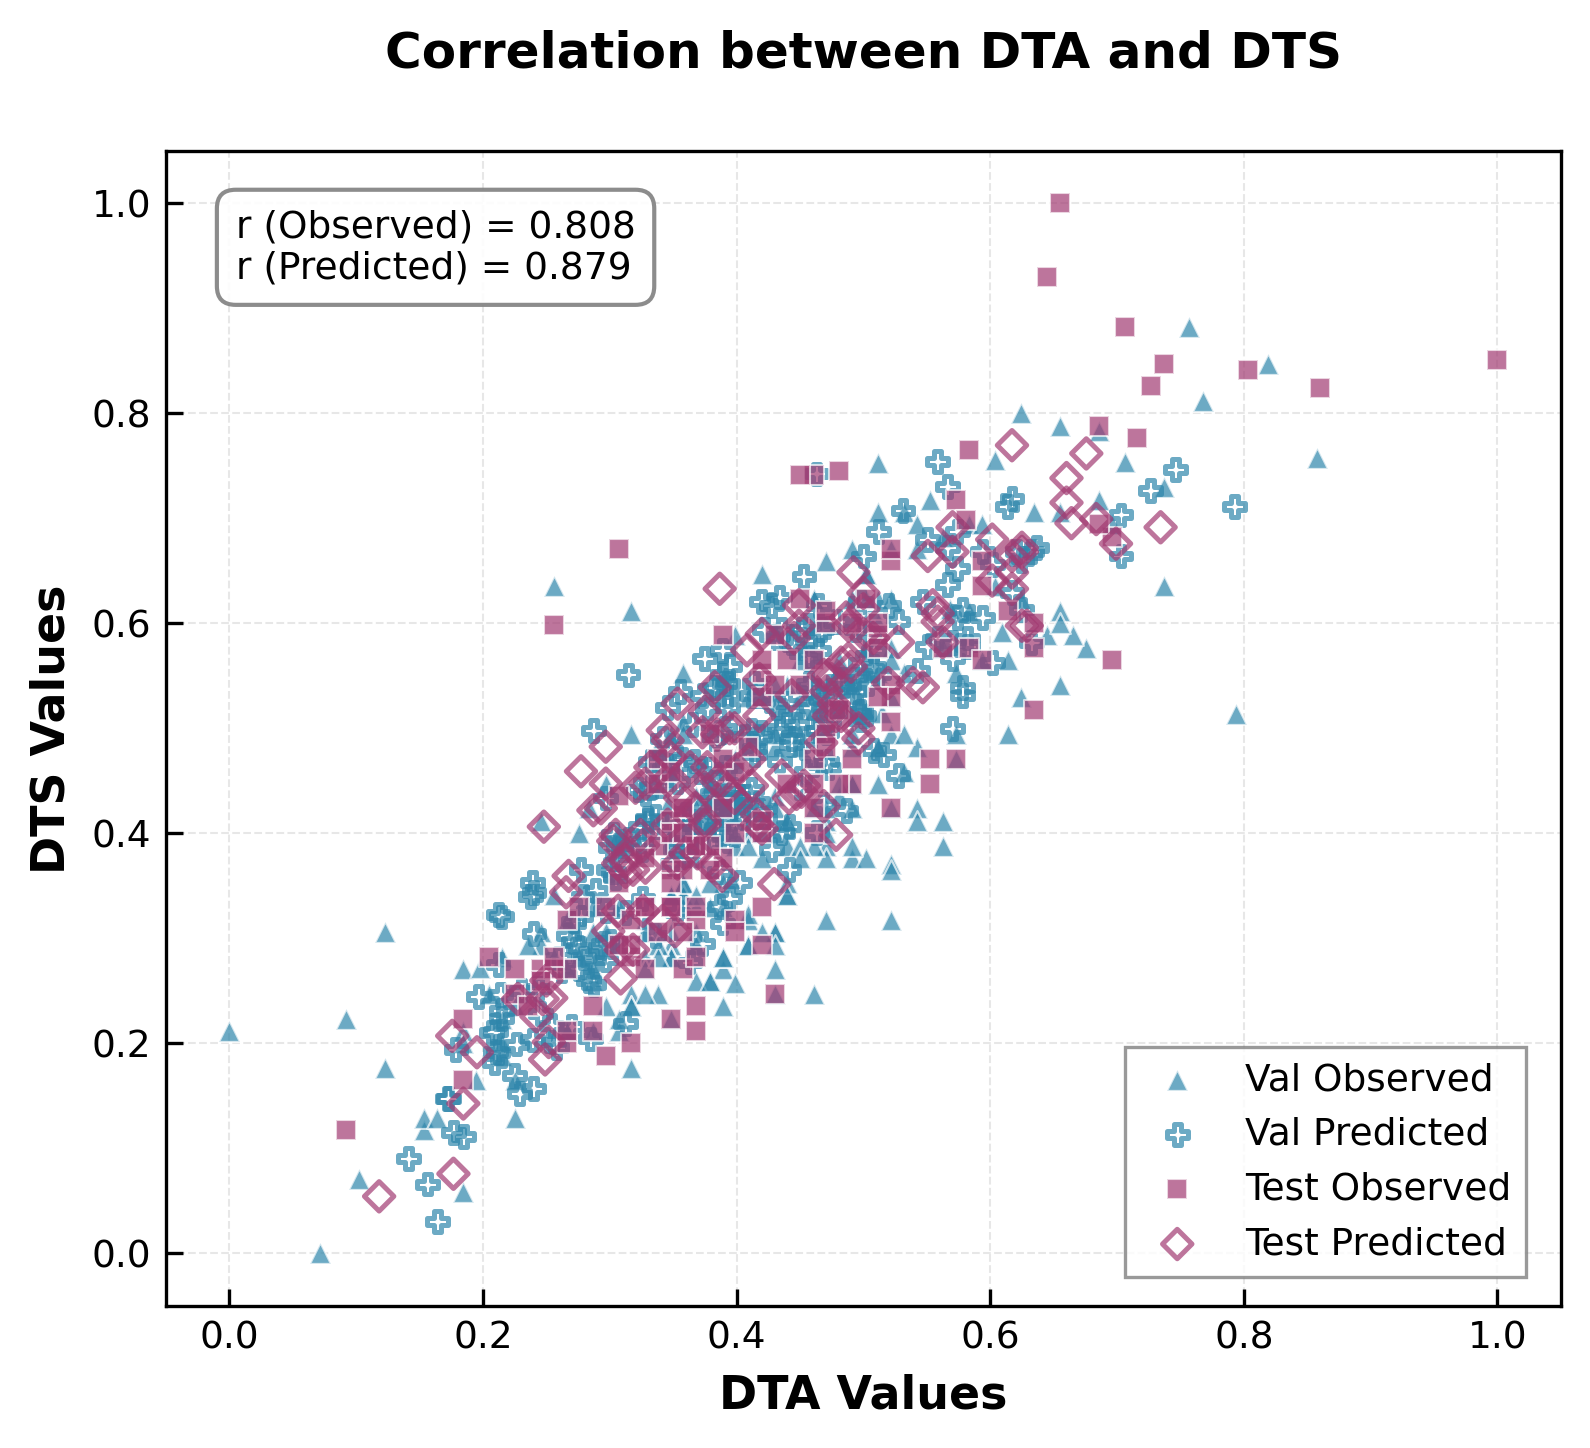

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

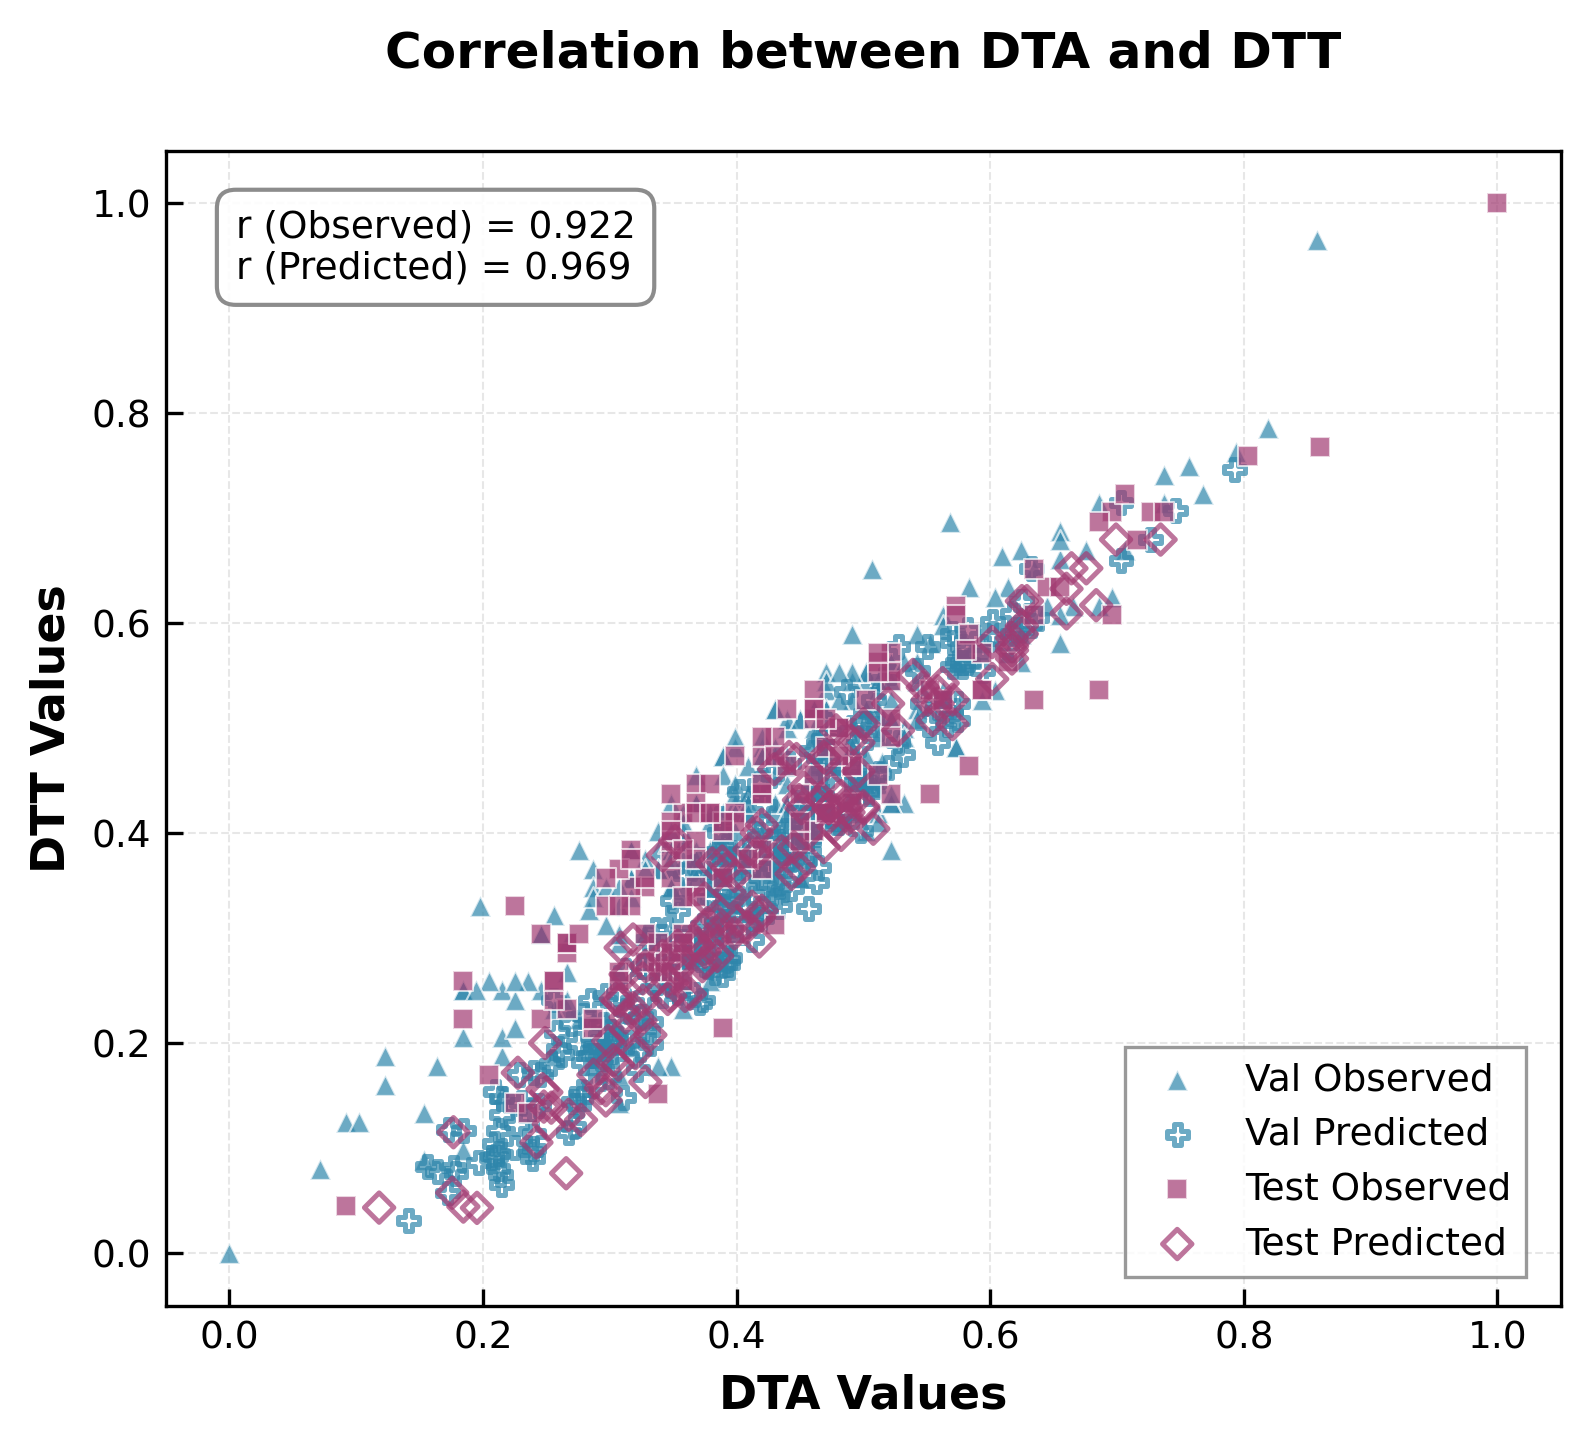

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

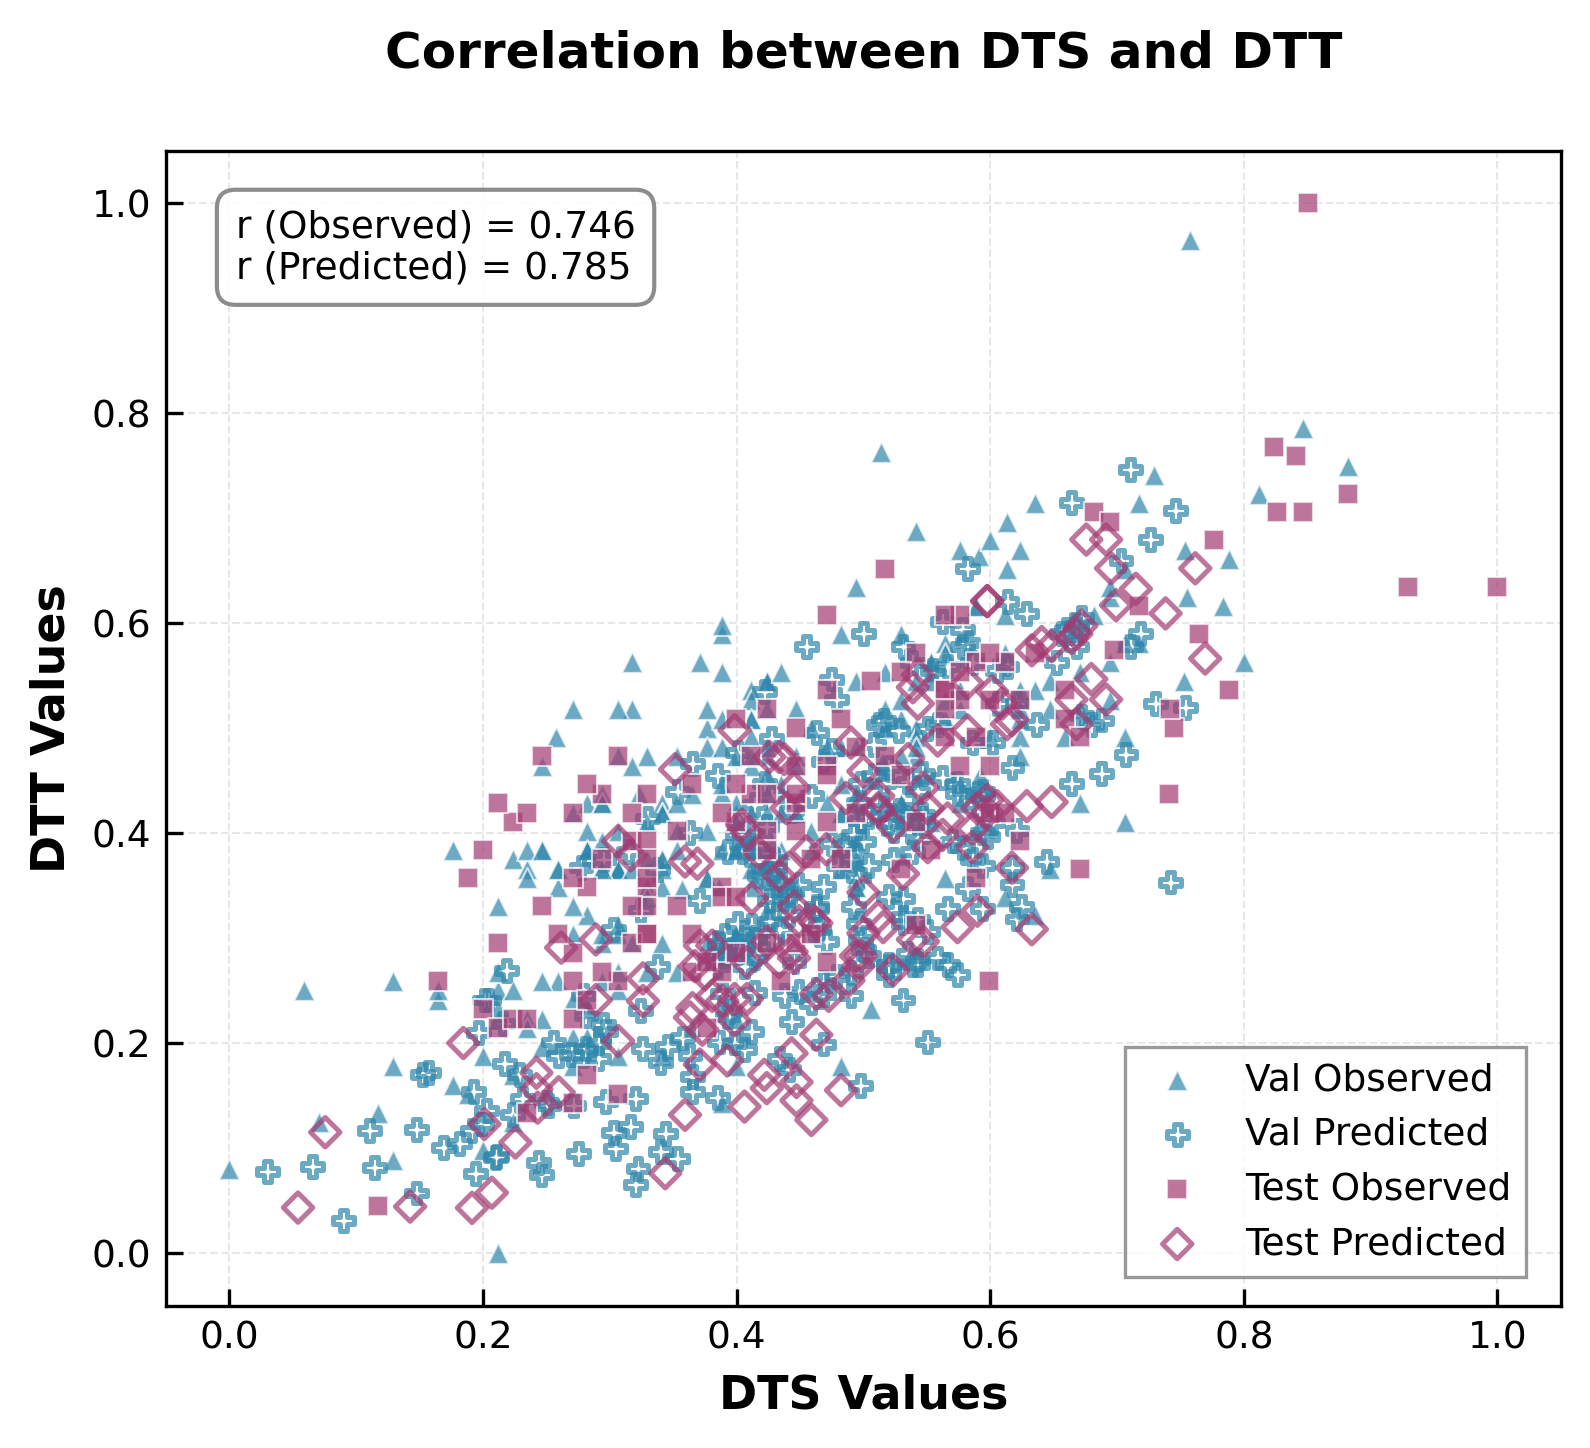

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np

# 设置学术论文风格的matplotlib参数
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

def plot_phenotype_correlation(phenotype1_prefix, phenotype2_prefix, val_csv_filepath=None, test_csv_filepath=None, train_csv_filepath=None):
    """
    Plot correlation between two phenotype predictions and true values.
    Load data from separate val, test, and train CSV files.
    Use different colors based on data source (val, test, train).
    Use different markers for predicted and true values.

    Parameters:
    phenotype1_prefix (str): Prefix for the first phenotype (e.g., 'env1').
    phenotype2_prefix (str): Prefix for the second phenotype (e.g., 'env4').
    val_csv_filepath (str, optional): Path to validation set CSV file.
    test_csv_filepath (str, optional): Path to test set CSV file.
    train_csv_filepath (str, optional): Path to training set CSV file.
    """
    dfs = []
    sources = []

    if val_csv_filepath:
        try:
            df_val = pd.read_csv(val_csv_filepath)
            df_val['split'] = 'val'
            dfs.append(df_val)
            sources.append('Validation')
        except FileNotFoundError:
            print(f"Warning: Validation file not found {val_csv_filepath}")
        except Exception as e:
            print(f"Error reading validation CSV file: {e}")

    if test_csv_filepath:
        try:
            df_test = pd.read_csv(test_csv_filepath)
            df_test['split'] = 'test'
            dfs.append(df_test)
            sources.append('Test')
        except FileNotFoundError:
            print(f"Warning: Test file not found {test_csv_filepath}")
        except Exception as e:
            print(f"Error reading test CSV file: {e}")

    if train_csv_filepath:
        try:
            df_train = pd.read_csv(train_csv_filepath)
            df_train['split'] = 'train'
            dfs.append(df_train)
            sources.append('Training')
        except FileNotFoundError:
            print(f"Warning: Training file not found {train_csv_filepath}")
        except Exception as e:
            print(f"Error reading training CSV file: {e}")

    if not dfs:
        print("Error: No valid data files provided or unable to read any data files.")
        return

    df = pd.concat(dfs, ignore_index=True)

    pred_col1 = f"{phenotype1_prefix}_pred"
    label_col1 = f"{phenotype1_prefix}_label"
    pred_col2 = f"{phenotype2_prefix}_pred"
    label_col2 = f"{phenotype2_prefix}_label"

    required_cols = [pred_col1, label_col1, pred_col2, label_col2, 'split']
    for col in required_cols:
        if col not in df.columns:
            print(f"Error: Missing column '{col}' in merged DataFrame. Please check CSV files.")
            return

    # 创建学术风格的图形
    fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
    
    # 学术论文友好的颜色方案 - 使用深色和中性色调
    colors_map = {
        'train': '#F18F01',    # 深蓝色
        'test': '#A23B72',     # 深紫红色  
        'val': '#2E86AB'      # 橙色
    }
    
    # 不同形状的标记符
    markers_true = {'train': 'o', 'test': 's', 'val': '^'}  # 圆形、方形、三角形
    markers_pred = {'train': 'v', 'test': 'D', 'val': 'P'}  # 倒三角、菱形、加号

    unique_splits = df['split'].unique()

    for split_value in unique_splits:
        split_df = df[df['split'] == split_value]
        color = colors_map.get(split_value.lower(), '#666666')
        
        # 绘制真实值 - 使用实心标记
        ax.scatter(split_df[label_col1], split_df[label_col2],
                  label=f'{split_value.capitalize()} Observed',
                  marker=markers_true[split_value], s=25, alpha=0.7, 
                  color=color, edgecolors='white', linewidth=0.5)
        
        # 绘制预测值 - 使用空心标记
        ax.scatter(split_df[pred_col1], split_df[pred_col2],
                  label=f'{split_value.capitalize()} Predicted',
                  marker=markers_pred[split_value], s=25, alpha=0.7, 
                  facecolors='none', edgecolors=color, linewidth=1.2)

    # 计算并标注整体相关系数
    if not df[label_col1].empty and not df[label_col2].empty:
        valid_true_indices = df[label_col1].notna() & df[label_col2].notna()
        if valid_true_indices.any():
             corr_true, _ = pearsonr(df.loc[valid_true_indices, label_col1], df.loc[valid_true_indices, label_col2])
        else:
            corr_true = float('nan')
    else:
        corr_true = float('nan')

    if not df[pred_col1].empty and not df[pred_col2].empty:
        valid_pred_indices = df[pred_col1].notna() & df[pred_col2].notna()
        if valid_pred_indices.any():
            corr_pred, _ = pearsonr(df.loc[valid_pred_indices, pred_col1], df.loc[valid_pred_indices, pred_col2])
        else:
            corr_pred = float('nan')
    else:
        corr_pred = float('nan')

    # 学术风格的文本框
    textstr = f'r (Observed) = {corr_true:.3f}\nr (Predicted) = {corr_pred:.3f}'
    props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props)

    # 设置坐标轴标签
    ax.set_xlabel(f'{phenotype1_prefix.upper()} Values', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'{phenotype2_prefix.upper()} Values', fontsize=11, fontweight='bold')
    
    # 设置标题
    title_sources = ' and '.join(sources) if sources else 'Data'
    ax.set_title(f'Correlation between {phenotype1_prefix.upper()} and {phenotype2_prefix.upper()}', 
                fontsize=12, fontweight='bold', pad=20)
    
    # 设置图例 - 学术风格
    legend = ax.legend(bbox_to_anchor=(0.975, 0.025), loc='lower right', borderaxespad=0,
                      frameon=True, fancybox=False, shadow=False, fontsize=9)

    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('gray')
    legend.get_frame().set_linewidth(0.8)
    
    # 设置网格 - 更加精细
    ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)
    
    # 设置坐标轴刻度
    ax.tick_params(axis='both', which='major', labelsize=9, direction='in', length=4)
    
    # 调整布局以适应图例
    # plt.tight_layout()
    # plt.subplots_adjust(right=0.75)
    
    plt.show()

# 使用示例:
val_file = '/media/marxin/softs/workspace/Whisper_of_DNA_pl/logs0/DNAWhisper/run12_blockembedding_f3p_30k/val_predictions.csv'
test_file = '/media/marxin/softs/workspace/Whisper_of_DNA_pl/logs0/DNAWhisper/run12_blockembedding_f3p_30k/test_predictions.csv'

# Plot correlation between ENV1 and ENV4 using validation and test datasets
plot_phenotype_correlation(phenotype1_prefix='DTA', phenotype2_prefix='DTS', val_csv_filepath=val_file, test_csv_filepath=test_file)

# Plot correlation between ENV2 and ENV4
plot_phenotype_correlation(phenotype1_prefix='DTA', phenotype2_prefix='DTT', val_csv_filepath=val_file, test_csv_filepath=test_file)

# Plot correlation between ENV3 and ENV4
plot_phenotype_correlation(phenotype1_prefix='DTS', phenotype2_prefix='DTT', val_csv_filepath=val_file, test_csv_filepath=test_file)